
# AHS-KT × Algebra2005：无泄露 Question-level 5 折 × 多 seed × Ablation

> **重要修正**：不要把一题多知识点的原始行直接展开成多个连续时间步来训练/评估 AHS-KT。

Algebra2005 里很多原始题目步骤的 `KC(Default)` 包含多个知识点，用 `~~` 分隔。如果把同一行展开成多条 concept-level 交互，模型会在 `t -> t+1` 预测时看到**同一次作答的同一个 response 标签**，这会造成同题标签泄露，使 AUC / F1 偏高。

本 Notebook 改成无泄露方案：

1. **时间轴按原始 question-step 保持一行一个时间步**；
2. 对多 KC 行，不再展开；
3. 为了兼容当前 `AHSKTModel` 只接受单个 `concept_id` 的接口，把排序归一化后的 KC 集合作为一个 `concept_combo_id`；
4. 每个 validation fold 单独只用 train split 拟合 difficulty 与 behavior cluster；
5. 跑 `5 folds × 多 seeds × ablation` 并导出对照表。

这不是最理想的 multi-hot KC 表示。更理想的长期方案是改模型，让 `concept_ids` 支持 multi-hot / set encoder。但在“不改模型接口”的前提下，`question-level + combo concept` 是最短且避免同题标签泄露的路线。

In [1]:

from pathlib import Path
import os
import sys
import json
import time
import random
import gc

PROJECT_ROOT = Path('/root/autodl-tmp/ahs-kt')
SRC_ROOT = PROJECT_ROOT / 'src'
AL2005_DIR = PROJECT_ROOT / 'data' / 'AL2005'

THREAD_ENV = {
    'OMP_NUM_THREADS': '1',
    'OPENBLAS_NUM_THREADS': '1',
    'MKL_NUM_THREADS': '1',
    'NUMEXPR_NUM_THREADS': '1',
    'VECLIB_MAXIMUM_THREADS': '1',
    'GOTO_NUM_THREADS': '1',
}
for key, value in THREAD_ENV.items():
    os.environ[key] = value

assert PROJECT_ROOT.exists(), f'找不到项目目录: {PROJECT_ROOT}'
assert AL2005_DIR.exists(), f'找不到 AL2005 目录: {AL2005_DIR}'
assert (AL2005_DIR / 'algebra_2005_2006_train.txt').exists(), '缺少 algebra_2005_2006_train.txt'
assert (AL2005_DIR / 'train_valid.csv').exists(), '缺少 train_valid.csv'
assert (AL2005_DIR / 'test.csv').exists(), '缺少 test.csv'
assert (AL2005_DIR / 'keyid2idx.json').exists(), '缺少 keyid2idx.json'

os.chdir(PROJECT_ROOT)
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('AL2005_DIR =', AL2005_DIR)
for key in THREAD_ENV:
    print(f'{key}={os.environ[key]}')


PROJECT_ROOT = /root/autodl-tmp/ahs-kt
AL2005_DIR = /root/autodl-tmp/ahs-kt/data/AL2005
OMP_NUM_THREADS=1
OPENBLAS_NUM_THREADS=1
MKL_NUM_THREADS=1
NUMEXPR_NUM_THREADS=1
VECLIB_MAXIMUM_THREADS=1
GOTO_NUM_THREADS=1


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from ahskt.config import load_config
from ahskt.data.dataset import SequenceBundle
from ahskt.models.ahs_kt import AHSKTModel
from ahskt.training.engine import fit_and_evaluate

print('TensorFlow version =', tf.__version__)
print('GPU devices =', tf.config.list_physical_devices('GPU'))
for gpu_device in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 200)


TensorFlow version = 2.8.0
GPU devices = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. 实验参数

默认跑完整小规模实验：

- 5 个 validation folds；
- 3 个 seeds；
- 4 个 ablation 设置；
- 每个 run 训练 3 个 epoch，patience=2。

如果只是调试 Notebook，可以先把 `VALID_FOLDS=[0]`、`SEED_LIST=[2026]`、`EPOCHS=1`。

In [3]:

VALID_FOLDS = [0, 1, 2, 3, 4]
SEED_LIST = [2024, 2025, 2026]
FEATURE_SEED = 2026
SEQUENCE_LENGTH = 200
REMAINDER_MIN_LEN = 3
N_BEHAVIOR_CLUSTERS = 4
QUESTION_ALPHA = 5.0
CONCEPT_ALPHA = 20.0
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 0.001
PATIENCE = 3
REUSE_FOLD_BUNDLES = True
REUSE_EXISTING_RUNS = True

TASK_NAME = 'ahskt_algebra2005_quelevel_cv_ablation'
DATA_CACHE_ROOT = PROJECT_ROOT / 'data' / 'algebra2005_quelevel_cv_ablation'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'algebra2005_quelevel_cv_ablation'
GENERATED_CONFIG_ROOT = OUTPUT_ROOT / 'generated_configs'
RUNS_ROOT = OUTPUT_ROOT / 'runs'
MANIFEST_PATH = OUTPUT_ROOT / f'{TASK_NAME}_manifest.json'
RAW_JSON_PATH = OUTPUT_ROOT / f'{TASK_NAME}_raw.json'
RAW_CSV_PATH = OUTPUT_ROOT / f'{TASK_NAME}_raw.csv'
AGG_JSON_PATH = OUTPUT_ROOT / f'{TASK_NAME}_aggregate.json'
AGG_CSV_PATH = OUTPUT_ROOT / f'{TASK_NAME}_aggregate.csv'
FOLD_AGG_JSON_PATH = OUTPUT_ROOT / f'{TASK_NAME}_fold_aggregate.json'
FOLD_AGG_CSV_PATH = OUTPUT_ROOT / f'{TASK_NAME}_fold_aggregate.csv'
ABLATION_TABLE_JSON_PATH = OUTPUT_ROOT / f'{TASK_NAME}_ablation_table.json'
ABLATION_TABLE_CSV_PATH = OUTPUT_ROOT / f'{TASK_NAME}_ablation_table.csv'
HISTORY_JSON_PATH = OUTPUT_ROOT / f'{TASK_NAME}_history.json'
HISTORY_CSV_PATH = OUTPUT_ROOT / f'{TASK_NAME}_history.csv'

EXPERIMENT_SPECS = {
    'target_only': {
        'label': 'Target Only',
        'description': '只保留 target interaction 主干，不使用 difficulty / behavior。',
        'model_overrides': {
            'use_behavior_cluster': False,
            'use_difficulty_features': False,
            'use_behavior_features': False,
            'use_target_interaction': True,
            'fusion_mode': 'late_residual',
            'behavior_condition_on_difficulty': False,
            'aux_residual_scale': 0.1,
            'difficulty_mode': 'smoothed_target_calibration',
            'difficulty_bias_scale': 0.05,
            'difficulty_feature_source': 'question_only',
        },
    },
    'difficulty_only': {
        'label': '+ Difficulty',
        'description': '保留 question/combo difficulty，移除 behavior。',
        'model_overrides': {
            'use_behavior_cluster': False,
            'use_difficulty_features': True,
            'use_behavior_features': False,
            'use_target_interaction': True,
            'fusion_mode': 'late_residual',
            'behavior_condition_on_difficulty': False,
            'aux_residual_scale': 0.1,
            'difficulty_mode': 'smoothed_target_calibration',
            'difficulty_bias_scale': 0.05,
            'difficulty_feature_source': 'question_only',
        },
    },
    'behavior_only': {
        'label': '+ Behavior',
        'description': '保留 attempts / hints / speed / cluster，移除 difficulty。',
        'model_overrides': {
            'use_behavior_cluster': True,
            'use_difficulty_features': False,
            'use_behavior_features': True,
            'use_target_interaction': True,
            'fusion_mode': 'late_residual',
            'behavior_condition_on_difficulty': False,
            'aux_residual_scale': 0.1,
            'difficulty_mode': 'smoothed_target_calibration',
            'difficulty_bias_scale': 0.05,
            'difficulty_feature_source': 'question_only',
        },
    },
    'full': {
        'label': '+ Difficulty + Behavior',
        'description': '完整 AHS-KT：question/combo difficulty + behavior + cluster。',
        'model_overrides': {
            'use_behavior_cluster': True,
            'use_difficulty_features': True,
            'use_behavior_features': True,
            'use_target_interaction': True,
            'fusion_mode': 'late_residual',
            'behavior_condition_on_difficulty': False,
            'aux_residual_scale': 0.1,
            'difficulty_mode': 'smoothed_target_calibration',
            'difficulty_bias_scale': 0.05,
            'difficulty_feature_source': 'question_only',
        },
    },
}

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DATA_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
GENERATED_CONFIG_ROOT.mkdir(parents=True, exist_ok=True)
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print('VALID_FOLDS =', VALID_FOLDS)
print('SEED_LIST =', SEED_LIST)
print('FEATURE_SEED =', FEATURE_SEED)
print('EXPERIMENTS =', list(EXPERIMENT_SPECS))
print('OUTPUT_ROOT =', OUTPUT_ROOT)


VALID_FOLDS = [0, 1, 2, 3, 4]
SEED_LIST = [2024, 2025, 2026]
FEATURE_SEED = 2026
EXPERIMENTS = ['target_only', 'difficulty_only', 'behavior_only', 'full']
OUTPUT_ROOT = /root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation



## 2. 读取切分与原始 question-level 日志

关键点：这里**不 explode `KC(Default)`**。

- 一条原始 DataShop 行 = 一个时间步；
- `concept_id` 实际是 `concept_combo_id`；
- 多 KC 组合先排序去重后再映射成一个整数 ID；
- 这样不会出现同一道题同一个 response 在相邻时间步反复出现的泄露问题。

In [4]:

def normalize_kc_combo(value: str) -> str:
    parts = [part.strip() for part in str(value).split('~~') if part.strip()]
    return '~~'.join(sorted(set(parts)))

with (AL2005_DIR / 'keyid2idx.json').open('r', encoding='utf-8') as f:
    keyid2idx = json.load(f)
uid_map = {str(key): int(value) for key, value in keyid2idx['uid'].items()}

train_valid_split = pd.read_csv(AL2005_DIR / 'train_valid.csv', usecols=['fold', 'uid'])
test_split = pd.read_csv(AL2005_DIR / 'test.csv', usecols=['uid'])
uid_to_fold = {int(row.uid): int(row.fold) for row in train_valid_split.itertuples(index=False)}
test_uids = set(test_split['uid'].astype(int))
all_uids = set(uid_to_fold) | test_uids

fold_user_summary = []
for fold in VALID_FOLDS:
    fold_user_summary.append({
        'fold': fold,
        'train_users': int((train_valid_split['fold'] != fold).sum()),
        'valid_users': int((train_valid_split['fold'] == fold).sum()),
        'test_users': len(test_uids),
    })
fold_user_summary_df = pd.DataFrame(fold_user_summary)
display(fold_user_summary_df)

raw = pd.read_csv(
    AL2005_DIR / 'algebra_2005_2006_train.txt',
    sep='	',
    usecols=[
        'Row',
        'Anon Student Id',
        'Problem Name',
        'Step Name',
        'Correct First Attempt',
        'Incorrects',
        'Hints',
        'Corrects',
        'Step Duration (sec)',
        'KC(Default)',
    ],
    dtype='string',
    low_memory=False,
)
raw['uid'] = raw['Anon Student Id'].map(uid_map)
raw = raw[raw['uid'].notna()].copy()
raw['uid'] = raw['uid'].astype(np.int32)
raw = raw[raw['uid'].isin(all_uids)].copy()
raw = raw[raw['KC(Default)'].notna() & (raw['KC(Default)'] != '')].copy()
raw = raw[raw['Correct First Attempt'].isin(['0', '1'])].copy()

raw['row_id'] = pd.to_numeric(raw['Row'], errors='coerce').fillna(0).astype(np.int64)
raw['response'] = raw['Correct First Attempt'].astype(np.int32)
raw['incorrects'] = pd.to_numeric(raw['Incorrects'], errors='coerce').fillna(0).clip(lower=0).astype(np.float32)
raw['hints_raw'] = pd.to_numeric(raw['Hints'], errors='coerce').fillna(0).clip(lower=0).astype(np.float32)
raw['corrects'] = pd.to_numeric(raw['Corrects'], errors='coerce').fillna(1).clip(lower=0).astype(np.float32)

duration = pd.to_numeric(raw['Step Duration (sec)'], errors='coerce')
median_duration = float(duration.dropna().median()) if duration.notna().any() else 15.0
if not np.isfinite(median_duration) or median_duration <= 0:
    median_duration = 15.0
raw['duration_sec'] = duration.fillna(median_duration).clip(lower=1.0).astype(np.float32)

raw['attempt_count_raw'] = (raw['incorrects'] + raw['corrects']).clip(lower=1.0).astype(np.float32)
raw['hint_count_raw'] = raw['hints_raw'].astype(np.float32)
raw['speed_raw'] = (60.0 / raw['duration_sec']).astype(np.float32)
raw['question_key'] = raw['Problem Name'].fillna('') + '----' + raw['Step Name'].fillna('')
raw['concept_combo_key'] = raw['KC(Default)'].apply(normalize_kc_combo)

question_level_base_df = raw[[
    'uid', 'question_key', 'concept_combo_key', 'response',
    'attempt_count_raw', 'hint_count_raw', 'speed_raw', 'duration_sec', 'row_id'
]].copy()
question_level_base_df['question_id'] = pd.factorize(question_level_base_df['question_key'], sort=True)[0].astype(np.int32) + 1
question_level_base_df['concept_id'] = pd.factorize(question_level_base_df['concept_combo_key'], sort=True)[0].astype(np.int32) + 1
question_level_base_df = question_level_base_df.sort_values(['uid', 'row_id']).reset_index(drop=True)

base_summary_df = pd.DataFrame([
    {'metric': 'students', 'value': question_level_base_df['uid'].nunique()},
    {'metric': 'question_level_interactions', 'value': len(question_level_base_df)},
    {'metric': 'unique_questions', 'value': question_level_base_df['question_id'].nunique()},
    {'metric': 'unique_concept_combos', 'value': question_level_base_df['concept_id'].nunique()},
    {'metric': 'correct_rate', 'value': question_level_base_df['response'].mean()},
])
display(base_summary_df)
assert len(question_level_base_df) == 607025, f'question-level interactions mismatch: {len(question_level_base_df)}'
question_level_base_df.head(5)


,fold,train_users,valid_users,test_users
0,0,368,92,114
1,1,368,92,114
2,2,368,92,114
3,3,368,92,114
4,4,368,92,114


,metric,value
0,students,574.000000
1,question_level_interactions,607025.000000
2,unique_questions,173113.000000
3,unique_concept_combos,291.000000
4,correct_rate,0.755288


,uid,question_key,concept_combo_key,response,attempt_count_raw,hint_count_raw,speed_raw,duration_sec,row_id,question_id,concept_id
0,0,EG4-FIXED----3(x+2) = 15,"[SkillRule: Eliminate Parens; {CLT nested; CLT nested, parens; Distribute Mult right; Distribute Mult left; (+/-x +/-a)/b=c, mult; (+/-x +/-a)*b=c, div; [var expr]/[const expr] = [const expr], mul...",0,3.0,3.0,1.500000,40.0,1,34501,173
1,0,EG4-FIXED----x+2 = 5,"[SkillRule: Isolate positive; x+a=b, positive]~~[SkillRule: Remove constant; {ax+b=c, positive; ax+b=c, negative; x+a=b, positive; x+a=b, negative; [var expr]+[const expr]=[const expr], positive; ...",1,1.0,0.0,3.750000,16.0,2,34507,190
2,0,EG40----2-8y = -4,"[SkillRule: Remove constant; {ax+b=c, positive; ax+b=c, negative; x+a=b, positive; x+a=b, negative; [var expr]+[const expr]=[const expr], positive; [var expr]+[const expr]=[const expr], negative; ...",0,3.0,3.0,1.666667,36.0,3,43861,209
3,0,EG40-----8y = -6,"[SkillRule: Remove coefficient; {ax+b=c, divide; ax=b; [const expr]*[var fact] + [const expr] = [const expr], divide; [var expr]*[const expr] = [const expr], divide; a/b*x=c; a/b*x=c, reciprocal; ...",1,1.0,0.0,2.727273,22.0,4,41084,205
4,0,EG40-----7y-5 = -4,"[SkillRule: Remove constant; {ax+b=c, positive; ax+b=c, negative; x+a=b, positive; x+a=b, negative; [var expr]+[const expr]=[const expr], positive; [var expr]+[const expr]=[const expr], negative; ...",1,1.0,0.0,0.508475,118.0,5,40476,211



## 3. 工具函数

这些函数用于：

- 每个 fold 单独拟合 difficulty / behavior；
- 构造 question-level AHS-KT bundle；
- 为每个 `(fold, experiment, seed)` 生成独立 config；
- 训练后补算 F1 并汇总。

In [5]:

def compute_smoothed_maps(frame: pd.DataFrame, id_col: str, response_col: str, alpha: float):
    grouped = frame.groupby(id_col)[response_col].agg(['sum', 'count'])
    global_mean = float(frame[response_col].mean()) if len(frame) else 0.5
    default_bin = int(np.clip(int(global_mean * 100) + 1, 1, 101))
    posterior = (grouped['sum'] + alpha * global_mean) / (grouped['count'] + alpha)
    bins = np.clip((posterior * 100).astype(int) + 1, 1, 101).astype(int)
    if alpha > 0:
        confidence = grouped['count'] / (grouped['count'] + alpha)
    else:
        confidence = pd.Series(np.ones(len(grouped), dtype=np.float32), index=grouped.index)
    return bins.to_dict(), posterior.astype(float).to_dict(), confidence.astype(float).to_dict(), default_bin, global_mean


def compute_behavior_columns(frame: pd.DataFrame, clip_values=None):
    attempts_raw = frame['attempt_count_raw'].to_numpy(dtype=np.float32)
    hints_raw = frame['hint_count_raw'].to_numpy(dtype=np.float32)
    speed_raw = frame['speed_raw'].to_numpy(dtype=np.float32)
    if clip_values is None:
        clip_values = {
            'attempts': float(np.quantile(attempts_raw, 0.99)),
            'hints': float(np.quantile(hints_raw, 0.99)),
            'speed': float(np.quantile(speed_raw, 0.99)),
        }
    attempts = np.log1p(np.clip(attempts_raw, 0.0, clip_values['attempts'])).astype(np.float32)
    hints = np.log1p(np.clip(hints_raw, 0.0, clip_values['hints'])).astype(np.float32)
    speed = np.log1p(np.clip(speed_raw, 0.0, clip_values['speed'])).astype(np.float32)
    features = np.stack([attempts, hints, speed], axis=-1)
    return attempts, hints, speed, clip_values, features


def build_cluster_mapping(raw_centers: np.ndarray):
    order = sorted(
        range(len(raw_centers)),
        key=lambda idx: (float(raw_centers[idx, 0]), float(raw_centers[idx, 1]), float(-raw_centers[idx, 2])),
    )
    return {int(old_label): int(new_label + 1) for new_label, old_label in enumerate(order)}


def fit_behavior_clusters(train_frame: pd.DataFrame, random_state: int):
    _, _, _, clip_values, features = compute_behavior_columns(train_frame)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)
    cluster_model = MiniBatchKMeans(
        n_clusters=N_BEHAVIOR_CLUSTERS,
        random_state=random_state,
        n_init=20,
        batch_size=4096,
    )
    cluster_model.fit(scaled_features)
    raw_centers = scaler.inverse_transform(cluster_model.cluster_centers_)
    cluster_mapping = build_cluster_mapping(raw_centers)
    centers = []
    for old_label, center in enumerate(raw_centers):
        cluster_id = cluster_mapping[int(old_label)]
        centers.append({
            'cluster_id': int(cluster_id),
            'attempts_log_center': float(center[0]),
            'hints_log_center': float(center[1]),
            'speed_log_center': float(center[2]),
            'attempts_raw_center': float(np.expm1(center[0])),
            'hints_raw_center': float(np.expm1(center[1])),
            'speed_raw_center': float(np.expm1(center[2])),
        })
    centers = sorted(centers, key=lambda item: item['cluster_id'])
    return clip_values, scaler, cluster_model, cluster_mapping, centers


def attach_behavior_features(frame: pd.DataFrame, clip_values, scaler, cluster_model, cluster_mapping) -> pd.DataFrame:
    attempts, hints, speed, _, features = compute_behavior_columns(frame, clip_values=clip_values)
    scaled_features = scaler.transform(features)
    raw_labels = cluster_model.predict(scaled_features)
    cluster_ids = np.array([cluster_mapping[int(raw_label)] for raw_label in raw_labels], dtype=np.int32)
    enriched = frame.copy()
    enriched['attempts'] = attempts
    enriched['hints'] = hints
    enriched['speed'] = speed
    enriched['behavior_cluster'] = cluster_ids
    return enriched


def build_sequence_bundle(
    frame: pd.DataFrame,
    split_name: str,
    sequence_length: int,
    remainder_min_len: int,
    q_diff_map: dict,
    c_diff_map: dict,
    default_q_diff: int,
    default_c_diff: int,
    q_ease_map: dict,
    c_ease_map: dict,
    q_conf_map: dict,
    c_conf_map: dict,
    default_q_ease: float,
    default_c_ease: float,
    default_confidence: float = 0.0,
) -> SequenceBundle:
    split_frame = frame[frame['split'] == split_name].copy()
    records = []
    for uid, student in split_frame.groupby('uid'):
        student = student.sort_values(['row_id'])
        payload = {
            'question_ids': student['question_id'].to_numpy(dtype=np.int32),
            'concept_ids': student['concept_id'].to_numpy(dtype=np.int32),
            'responses': student['response'].to_numpy(dtype=np.int32),
            'question_difficulty': student['question_id'].map(q_diff_map).fillna(default_q_diff).to_numpy(dtype=np.int32),
            'concept_difficulty': student['concept_id'].map(c_diff_map).fillna(default_c_diff).to_numpy(dtype=np.int32),
            'attempts': student['attempts'].to_numpy(dtype=np.float32),
            'hints': student['hints'].to_numpy(dtype=np.float32),
            'speed': student['speed'].to_numpy(dtype=np.float32),
            'behavior_cluster': student['behavior_cluster'].to_numpy(dtype=np.int32),
            'question_easiness': student['question_id'].map(q_ease_map).fillna(default_q_ease).to_numpy(dtype=np.float32),
            'concept_easiness': student['concept_id'].map(c_ease_map).fillna(default_c_ease).to_numpy(dtype=np.float32),
            'question_confidence': student['question_id'].map(q_conf_map).fillna(default_confidence).to_numpy(dtype=np.float32),
            'concept_confidence': student['concept_id'].map(c_conf_map).fillna(default_confidence).to_numpy(dtype=np.float32),
        }
        total_len = len(student)
        for start in range(0, total_len, sequence_length):
            end = min(start + sequence_length, total_len)
            current_len = end - start
            if current_len < max(2, remainder_min_len):
                continue
            records.append({key: values[start:end] for key, values in payload.items()})
    if not records:
        raise ValueError(f'{split_name} split 没有可用序列')

    num_records = len(records)
    arrays = {
        'question_ids': np.zeros((num_records, sequence_length), dtype=np.int32),
        'concept_ids': np.zeros((num_records, sequence_length), dtype=np.int32),
        'responses': np.zeros((num_records, sequence_length), dtype=np.int32),
        'question_difficulty': np.zeros((num_records, sequence_length), dtype=np.int32),
        'concept_difficulty': np.zeros((num_records, sequence_length), dtype=np.int32),
        'attempts': np.zeros((num_records, sequence_length), dtype=np.float32),
        'hints': np.zeros((num_records, sequence_length), dtype=np.float32),
        'speed': np.zeros((num_records, sequence_length), dtype=np.float32),
        'behavior_cluster': np.zeros((num_records, sequence_length), dtype=np.int32),
        'mask': np.zeros((num_records, sequence_length), dtype=np.int32),
        'question_easiness': np.zeros((num_records, sequence_length), dtype=np.float32),
        'concept_easiness': np.zeros((num_records, sequence_length), dtype=np.float32),
        'question_confidence': np.zeros((num_records, sequence_length), dtype=np.float32),
        'concept_confidence': np.zeros((num_records, sequence_length), dtype=np.float32),
    }
    for row_idx, record in enumerate(records):
        valid_len = len(record['question_ids'])
        for key, values in record.items():
            arrays[key][row_idx, :valid_len] = values
        arrays['mask'][row_idx, :valid_len] = 1
    return SequenceBundle(**arrays)


def save_bundle_npz(bundle: SequenceBundle, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(output_path, **bundle.as_dict())


def load_bundle_npz(npz_path: Path) -> SequenceBundle:
    payload = np.load(npz_path, allow_pickle=False)
    return SequenceBundle(**{key: payload[key] for key in payload.files})


def assign_fold_split(base_df: pd.DataFrame, valid_fold: int) -> pd.DataFrame:
    fold_df = base_df.copy()
    uid_fold = fold_df['uid'].map(uid_to_fold)
    fold_df['split'] = np.where(
        fold_df['uid'].isin(test_uids),
        'test',
        np.where(uid_fold == valid_fold, 'valid', 'train'),
    )
    return fold_df


def prepare_fold_assets(valid_fold: int):
    fold_dir = DATA_CACHE_ROOT / f'fold_{valid_fold}'
    train_npz = fold_dir / 'train_ahskt.npz'
    valid_npz = fold_dir / 'valid_ahskt.npz'
    test_npz = fold_dir / 'test_ahskt.npz'
    metadata_path = fold_dir / 'metadata.json'

    if REUSE_FOLD_BUNDLES and train_npz.exists() and valid_npz.exists() and test_npz.exists() and metadata_path.exists():
        return {
            'fold': valid_fold,
            'fold_dir': fold_dir,
            'train_npz': train_npz,
            'valid_npz': valid_npz,
            'test_npz': test_npz,
            'train_bundle': load_bundle_npz(train_npz),
            'valid_bundle': load_bundle_npz(valid_npz),
            'test_bundle': load_bundle_npz(test_npz),
            'metadata': json.loads(metadata_path.read_text(encoding='utf-8')),
        }

    fold_df = assign_fold_split(question_level_base_df, valid_fold)
    train_frame = fold_df[fold_df['split'] == 'train'].copy()

    q_diff_map, q_ease_map, q_conf_map, default_q_diff, question_global_ease = compute_smoothed_maps(
        train_frame, 'question_id', 'response', QUESTION_ALPHA
    )
    c_diff_map, c_ease_map, c_conf_map, default_c_diff, concept_global_ease = compute_smoothed_maps(
        train_frame, 'concept_id', 'response', CONCEPT_ALPHA
    )
    clip_values, scaler, cluster_model, cluster_mapping, cluster_centers = fit_behavior_clusters(
        train_frame, random_state=FEATURE_SEED + int(valid_fold)
    )
    fold_df = attach_behavior_features(fold_df, clip_values, scaler, cluster_model, cluster_mapping)

    train_bundle = build_sequence_bundle(
        fold_df, 'train', SEQUENCE_LENGTH, REMAINDER_MIN_LEN,
        q_diff_map, c_diff_map, default_q_diff, default_c_diff,
        q_ease_map, c_ease_map, q_conf_map, c_conf_map,
        question_global_ease, concept_global_ease,
    )
    valid_bundle = build_sequence_bundle(
        fold_df, 'valid', SEQUENCE_LENGTH, REMAINDER_MIN_LEN,
        q_diff_map, c_diff_map, default_q_diff, default_c_diff,
        q_ease_map, c_ease_map, q_conf_map, c_conf_map,
        question_global_ease, concept_global_ease,
    )
    test_bundle = build_sequence_bundle(
        fold_df, 'test', SEQUENCE_LENGTH, REMAINDER_MIN_LEN,
        q_diff_map, c_diff_map, default_q_diff, default_c_diff,
        q_ease_map, c_ease_map, q_conf_map, c_conf_map,
        question_global_ease, concept_global_ease,
    )

    fold_dir.mkdir(parents=True, exist_ok=True)
    save_bundle_npz(train_bundle, train_npz)
    save_bundle_npz(valid_bundle, valid_npz)
    save_bundle_npz(test_bundle, test_npz)

    metadata = {
        'fold': int(valid_fold),
        'representation': 'question_level_combo_concept_no_leak',
        'sequence_length': int(SEQUENCE_LENGTH),
        'remainder_min_len': int(REMAINDER_MIN_LEN),
        'num_questions': int(question_level_base_df['question_id'].max()),
        'num_concepts': int(question_level_base_df['concept_id'].max()),
        'concept_id_semantics': 'concept combo id, not atomic KC id',
        'num_question_difficulty': int(max(q_diff_map.values())),
        'num_concept_difficulty': int(max(c_diff_map.values())),
        'num_behavior_clusters': int(max(cluster_mapping.values()) + 1),
        'default_question_difficulty': int(default_q_diff),
        'default_concept_difficulty': int(default_c_diff),
        'smoothing': {
            'question_global_easiness': float(question_global_ease),
            'concept_global_easiness': float(concept_global_ease),
            'question_alpha': float(QUESTION_ALPHA),
            'concept_alpha': float(CONCEPT_ALPHA),
        },
        'behavior': {
            'n_real_clusters': int(N_BEHAVIOR_CLUSTERS),
            'clip_values': {key: float(value) for key, value in clip_values.items()},
            'cluster_centers': cluster_centers,
        },
        'split_summary': {
            'train_users': int(fold_df.loc[fold_df['split'] == 'train', 'uid'].nunique()),
            'valid_users': int(fold_df.loc[fold_df['split'] == 'valid', 'uid'].nunique()),
            'test_users': int(fold_df.loc[fold_df['split'] == 'test', 'uid'].nunique()),
            'train_sequences': int(train_bundle.num_samples),
            'valid_sequences': int(valid_bundle.num_samples),
            'test_sequences': int(test_bundle.num_samples),
            'train_interactions': int(train_bundle.mask.sum()),
            'valid_interactions': int(valid_bundle.mask.sum()),
            'test_interactions': int(test_bundle.mask.sum()),
        },
        'paths': {
            'train_npz': str(train_npz),
            'valid_npz': str(valid_npz),
            'test_npz': str(test_npz),
        },
    }
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

    return {
        'fold': valid_fold,
        'fold_dir': fold_dir,
        'train_npz': train_npz,
        'valid_npz': valid_npz,
        'test_npz': test_npz,
        'train_bundle': train_bundle,
        'valid_bundle': valid_bundle,
        'test_bundle': test_bundle,
        'metadata': metadata,
    }


def build_base_config_payload(fold_assets: dict) -> dict:
    metadata = fold_assets['metadata']
    return {
        'project_name': 'ahs-kt',
        'task_name': TASK_NAME,
        'seed': int(SEED_LIST[0]),
        'dataset': {
            'mode': 'real_npz',
            'train_path': str(fold_assets['train_npz'].relative_to(PROJECT_ROOT)),
            'valid_path': str(fold_assets['valid_npz'].relative_to(PROJECT_ROOT)),
            'test_path': str(fold_assets['test_npz'].relative_to(PROJECT_ROOT)),
        },
        'model': {
            'num_questions': int(metadata['num_questions']),
            'num_concepts': int(metadata['num_concepts']),
            'num_question_difficulty': int(metadata['num_question_difficulty']),
            'num_concept_difficulty': int(metadata['num_concept_difficulty']),
            'num_behavior_clusters': int(metadata['num_behavior_clusters']),
            'sequence_length': int(metadata['sequence_length']),
            'embedding_dim': 64,
            'difficulty_dim': 32,
            'behavior_dim': 32,
            'hidden_dim': 96,
            'dropout': 0.2,
            'use_behavior_cluster': True,
            'use_difficulty_features': True,
            'use_behavior_features': True,
            'use_target_interaction': True,
            'question_global_easiness': float(metadata['smoothing']['question_global_easiness']),
            'concept_global_easiness': float(metadata['smoothing']['concept_global_easiness']),
            'fusion_mode': 'late_residual',
            'behavior_condition_on_difficulty': False,
            'aux_residual_scale': 0.1,
            'difficulty_mode': 'smoothed_target_calibration',
            'difficulty_bias_scale': 0.05,
            'difficulty_feature_source': 'question_only',
        },
        'training': {
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'learning_rate': float(LEARNING_RATE),
            'patience': int(PATIENCE),
        },
        'demo': {
            'train_size': 0,
            'valid_size': 0,
            'test_size': 0,
        },
        'outputs': {
            'root_dir': str((RUNS_ROOT / 'base').relative_to(PROJECT_ROOT)),
        },
    }


def build_run_config_payload(base_payload: dict, fold: int, experiment_name: str, seed: int) -> dict:
    payload = json.loads(json.dumps(base_payload))
    spec = EXPERIMENT_SPECS[experiment_name]
    payload['seed'] = int(seed)
    payload['task_name'] = f'{TASK_NAME}_f{fold}_{experiment_name}_s{seed}'
    payload['outputs']['root_dir'] = str((RUNS_ROOT / f'fold_{fold}' / experiment_name / f'seed_{seed}').relative_to(PROJECT_ROOT))
    payload['model'].update(spec['model_overrides'])
    return payload


def collect_targets_and_predictions(model, bundle, batch_size):
    dataset = bundle.to_tf_dataset(batch_size=batch_size, shuffle=False)
    all_targets = []
    all_predictions = []
    for batch in dataset:
        logits = model(batch, training=False)
        next_logits = logits[:, :-1]
        next_targets = tf.cast(batch['responses'][:, 1:], tf.float32)
        next_mask = tf.cast(batch['mask'][:, 1:], tf.float32)
        valid_logits = tf.boolean_mask(next_logits, next_mask > 0)
        valid_targets = tf.boolean_mask(next_targets, next_mask > 0)
        all_targets.append(valid_targets.numpy())
        all_predictions.append(tf.sigmoid(valid_logits).numpy())
    return np.concatenate(all_targets, axis=0), np.concatenate(all_predictions, axis=0)



## 4. 实验计划总览

In [6]:

experiment_plan_df = pd.DataFrame([
    {
        'experiment': name,
        'label': spec['label'],
        'description': spec['description'],
        'use_difficulty_features': spec['model_overrides']['use_difficulty_features'],
        'use_behavior_features': spec['model_overrides']['use_behavior_features'],
        'use_behavior_cluster': spec['model_overrides']['use_behavior_cluster'],
    }
    for name, spec in EXPERIMENT_SPECS.items()
])

total_runs = len(VALID_FOLDS) * len(SEED_LIST) * len(EXPERIMENT_SPECS)
print('total_runs =', total_runs)
display(experiment_plan_df)


total_runs = 60


,experiment,label,description,use_difficulty_features,use_behavior_features,use_behavior_cluster
0,target_only,Target Only,只保留 target interaction 主干，不使用 difficulty / behavior。,False,False,False
1,difficulty_only,+ Difficulty,保留 question/combo difficulty，移除 behavior。,True,False,False
2,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,False,True,True
3,full,+ Difficulty + Behavior,完整 AHS-KT：question/combo difficulty + behavior + cluster。,True,True,True



## 5. 构建或复用 5 个 question-level fold bundle

In [7]:

fold_assets_map = {}
fold_summary_rows = []

for fold in VALID_FOLDS:
    fold_assets = prepare_fold_assets(fold)
    fold_assets_map[fold] = fold_assets
    meta = fold_assets['metadata']
    fold_summary_rows.append({
        'fold': int(fold),
        'train_users': meta['split_summary']['train_users'],
        'valid_users': meta['split_summary']['valid_users'],
        'test_users': meta['split_summary']['test_users'],
        'train_sequences': meta['split_summary']['train_sequences'],
        'valid_sequences': meta['split_summary']['valid_sequences'],
        'test_sequences': meta['split_summary']['test_sequences'],
        'train_interactions': meta['split_summary']['train_interactions'],
        'valid_interactions': meta['split_summary']['valid_interactions'],
        'test_interactions': meta['split_summary']['test_interactions'],
        'num_concept_combos': meta['num_concepts'],
    })

fold_summary_df = pd.DataFrame(fold_summary_rows).sort_values('fold').reset_index(drop=True)
display(fold_summary_df)


,fold,train_users,valid_users,test_users,train_sequences,valid_sequences,test_sequences,train_interactions,valid_interactions,test_interactions,num_concept_combos
0,0,368,92,114,2197,614,529,399763,113656,93594,291
1,1,368,92,114,2194,617,529,400768,112651,93594,291
2,2,368,92,114,2256,555,529,411998,101421,93594,291
3,3,368,92,114,2283,528,529,417814,95605,93594,291
4,4,368,92,114,2314,497,529,423333,90086,93594,291



## 6. 运行 5 折 × 多 seed × Ablation

如果结果文件已经存在，且 `REUSE_EXISTING_RUNS=True`，这一节会自动跳过已经完成的 run。

In [8]:

all_rows = []
all_history_rows = []
run_index = 0

for fold in VALID_FOLDS:
    fold_assets = fold_assets_map[fold]
    base_payload = build_base_config_payload(fold_assets)
    train_bundle = fold_assets['train_bundle']
    valid_bundle = fold_assets['valid_bundle']
    test_bundle = fold_assets['test_bundle']
    fold_meta = fold_assets['metadata']

    for experiment_name, experiment_spec in EXPERIMENT_SPECS.items():
        for seed in SEED_LIST:
            run_index += 1
            config_payload = build_run_config_payload(base_payload, fold, experiment_name, seed)
            config_dir = GENERATED_CONFIG_ROOT / f'fold_{fold}'
            config_dir.mkdir(parents=True, exist_ok=True)
            config_path = config_dir / f'{experiment_name}_seed{seed}.json'
            config_path.write_text(json.dumps(config_payload, ensure_ascii=False, indent=2), encoding='utf-8')

            config = load_config(config_path, project_root=PROJECT_ROOT)
            metrics_path = config.output_root / f'{config.task_name}_metrics.json'
            metrics_with_f1_path = config.output_root / f'{config.task_name}_metrics_with_f1.json'

            if REUSE_EXISTING_RUNS and metrics_path.exists() and metrics_with_f1_path.exists():
                metrics_summary = json.loads(metrics_path.read_text(encoding='utf-8'))
                summary_with_f1 = json.loads(metrics_with_f1_path.read_text(encoding='utf-8'))
            else:
                random.seed(seed)
                np.random.seed(seed)
                tf.random.set_seed(seed)
                tf.keras.backend.clear_session()
                model = AHSKTModel(config.model)
                train_start = time.time()
                metrics_summary = fit_and_evaluate(
                    model=model,
                    train_bundle=train_bundle,
                    valid_bundle=valid_bundle,
                    test_bundle=test_bundle,
                    config=config,
                )
                train_elapsed = time.time() - train_start
                metrics_path.write_text(json.dumps(metrics_summary, ensure_ascii=False, indent=2), encoding='utf-8')

                test_targets, test_predictions = collect_targets_and_predictions(
                    model=model,
                    bundle=test_bundle,
                    batch_size=config.training.batch_size,
                )
                test_binary_predictions = (test_predictions > 0.5).astype(int)
                summary_with_f1 = {
                    'acc': float(accuracy_score(test_targets, test_binary_predictions)),
                    'auc': float(roc_auc_score(test_targets, test_predictions)),
                    'f1': float(f1_score(test_targets, test_binary_predictions)),
                    'loss': float(metrics_summary['test_metrics']['loss']),
                    'rmse': float(metrics_summary['test_metrics']['rmse']),
                    'num_test_points': int(len(test_targets)),
                    'best_epoch': int(metrics_summary['best_epoch']),
                    'checkpoint_path': metrics_summary['checkpoint_path'],
                    'train_seconds': float(train_elapsed),
                }
                metrics_with_f1_path.write_text(json.dumps(summary_with_f1, ensure_ascii=False, indent=2), encoding='utf-8')
                del model
                gc.collect()

            if 'train_seconds' not in summary_with_f1:
                summary_with_f1['train_seconds'] = np.nan

            all_rows.append({
                'fold': int(fold),
                'experiment': experiment_name,
                'label': experiment_spec['label'],
                'description': experiment_spec['description'],
                'seed': int(seed),
                'use_difficulty_features': bool(experiment_spec['model_overrides']['use_difficulty_features']),
                'use_behavior_features': bool(experiment_spec['model_overrides']['use_behavior_features']),
                'use_behavior_cluster': bool(experiment_spec['model_overrides']['use_behavior_cluster']),
                'best_epoch': int(metrics_summary['best_epoch']),
                'best_valid_auc': float(metrics_summary['best_valid_auc']),
                'test_auc': float(summary_with_f1['auc']),
                'test_acc': float(summary_with_f1['acc']),
                'test_f1': float(summary_with_f1['f1']),
                'test_loss': float(summary_with_f1['loss']),
                'test_rmse': float(summary_with_f1['rmse']),
                'num_test_points': int(summary_with_f1['num_test_points']),
                'train_seconds': float(summary_with_f1['train_seconds']),
                'train_sequences': int(fold_meta['split_summary']['train_sequences']),
                'valid_sequences': int(fold_meta['split_summary']['valid_sequences']),
                'test_sequences': int(fold_meta['split_summary']['test_sequences']),
                'config_path': str(config_path),
                'metrics_path': str(metrics_path),
                'metrics_with_f1_path': str(metrics_with_f1_path),
                'checkpoint_path': str(summary_with_f1['checkpoint_path']),
            })

            for item in metrics_summary['history']:
                for split in ['train', 'valid']:
                    row = {
                        'fold': int(fold),
                        'experiment': experiment_name,
                        'label': experiment_spec['label'],
                        'seed': int(seed),
                        'epoch': int(item['epoch']),
                        'split': split,
                    }
                    row.update({key: float(value) for key, value in item[split].items()})
                    all_history_rows.append(row)

            print(
                f'[{run_index:02d}/{total_runs}] '
                f'fold={fold} exp={experiment_name} seed={seed} '
                f'auc={float(summary_with_f1["auc"]):.4f} '
                f'f1={float(summary_with_f1["f1"]):.4f} '
                f'sec={float(summary_with_f1["train_seconds"]):.1f}'
            )

raw_results_df = pd.DataFrame(all_rows).sort_values(['experiment', 'fold', 'seed']).reset_index(drop=True)
history_df = pd.DataFrame(all_history_rows).sort_values(['experiment', 'fold', 'seed', 'epoch', 'split']).reset_index(drop=True)
display(raw_results_df.head(12))


2026-04-13 20:54:51.074491: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 20:54:51.633847: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:d6:00.0, compute capability: 8.6


2026-04-13 20:54:52.518603: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


2026-04-13 20:54:53.014107: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8200


[01/60] fold=0 exp=target_only seed=2024 auc=0.8250 f1=0.8847 sec=24.5


[02/60] fold=0 exp=target_only seed=2025 auc=0.8265 f1=0.8844 sec=23.6


...

[57/60] fold=4 exp=behavior_only seed=2026 auc=0.8267 f1=0.8855 sec=33.5


[58/60] fold=4 exp=full seed=2024 auc=0.8280 f1=0.8855 sec=37.8


[59/60] fold=4 exp=full seed=2025 auc=0.8282 f1=0.8842 sec=37.7


[60/60] fold=4 exp=full seed=2026 auc=0.8268 f1=0.8849 sec=38.2


,fold,experiment,label,description,seed,use_difficulty_features,use_behavior_features,use_behavior_cluster,best_epoch,best_valid_auc,test_auc,test_acc,test_f1,test_loss,test_rmse,num_test_points,train_seconds,train_sequences,valid_sequences,test_sequences,config_path,metrics_path,metrics_with_f1_path,checkpoint_path
0,0,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,2024,False,True,True,1,0.823650,0.827633,0.815086,0.884904,0.411101,0.361682,93065,31.239321,2197,614,529,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/generated_configs/fold_0/behavior_only_seed2024.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2024/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2024_metrics.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2024/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2024_metrics_with_f1.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2024/checkpoints/ckpt-1
1,0,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,2025,False,True,True,1,0.823472,0.827431,0.815892,0.885116,0.411079,0.361757,93065,32.808140,2197,614,529,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/generated_configs/fold_0/behavior_only_seed2025.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2025/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2025_metrics.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2025/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2025_metrics_with_f1.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2025/checkpoints/ckpt-1
2,0,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,2026,False,True,True,1,0.821420,0.825185,0.815140,0.884698,0.414268,0.363290,93065,33.242337,2197,614,529,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/generated_configs/fold_0/behavior_only_seed2026.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2026/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2026_metrics.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2026/ahskt_algebra2005_quelevel_cv_ablation_f0_behavior_only_s2026_metrics_with_f1.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_0/behavior_only/seed_2026/checkpoints/ckpt-1
3,1,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,2024,False,True,True,1,0.828049,0.826094,0.813388,0.882201,0.416145,0.364163,93065,32.298676,2194,617,529,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/generated_configs/fold_1/behavior_only_seed2024.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_1/behavior_only/seed_2024/ahskt_algebra2005_quelevel_cv_ablation_f1_behavior_only_s2024_metrics.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_1/behavior_only/seed_2024/ahskt_algebra2005_quelevel_cv_ablation_f1_behavior_only_s2024_metrics_with_f1.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_1/behavior_only/seed_2024/checkpoints/ckpt-1
4,1,behavior_only,+ Behavior,保留 attempts / hints / speed / cluster，移除 difficulty。,2025,False,True,True,1,0.828218,0.825216,0.812411,0.881109,0.415465,0.364154,93065,31.866808,2194,617,529,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/generated_configs/fold_1/behavior_only_seed2025.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/runs/fold_1/behavior_only/seed_2025/ahskt_algebra2005_quelevel_cv_ablation_f1_behavior_only_s2025_metrics.json,/root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_


## 7. 汇总和 ablation 对照表

In [9]:

def mean_std_string(mean_value: float, std_value: float, digits: int = 4) -> str:
    return f'{mean_value:.{digits}f}±{std_value:.{digits}f}'

raw_results_df.to_json(RAW_JSON_PATH, orient='records', force_ascii=False, indent=2)
raw_results_df.to_csv(RAW_CSV_PATH, index=False)
history_df.to_json(HISTORY_JSON_PATH, orient='records', force_ascii=False, indent=2)
history_df.to_csv(HISTORY_CSV_PATH, index=False)

fold_aggregate_df = (
    raw_results_df.groupby(['experiment', 'label', 'fold'], as_index=False)
    .agg(
        runs=('seed', 'count'),
        best_valid_auc_mean=('best_valid_auc', 'mean'),
        best_valid_auc_std=('best_valid_auc', lambda s: float(s.std(ddof=0))),
        test_auc_mean=('test_auc', 'mean'),
        test_auc_std=('test_auc', lambda s: float(s.std(ddof=0))),
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', lambda s: float(s.std(ddof=0))),
        test_f1_mean=('test_f1', 'mean'),
        test_f1_std=('test_f1', lambda s: float(s.std(ddof=0))),
        test_loss_mean=('test_loss', 'mean'),
        test_loss_std=('test_loss', lambda s: float(s.std(ddof=0))),
        test_rmse_mean=('test_rmse', 'mean'),
        test_rmse_std=('test_rmse', lambda s: float(s.std(ddof=0))),
        train_seconds_mean=('train_seconds', 'mean'),
        train_seconds_std=('train_seconds', lambda s: float(s.std(ddof=0))),
    )
    .sort_values(['experiment', 'fold'])
    .reset_index(drop=True)
)

experiment_aggregate_df = (
    raw_results_df.groupby(['experiment', 'label', 'description'], as_index=False)
    .agg(
        runs=('seed', 'count'),
        folds=('fold', 'nunique'),
        seeds=('seed', 'nunique'),
        best_valid_auc_mean=('best_valid_auc', 'mean'),
        best_valid_auc_std=('best_valid_auc', lambda s: float(s.std(ddof=0))),
        test_auc_mean=('test_auc', 'mean'),
        test_auc_std=('test_auc', lambda s: float(s.std(ddof=0))),
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', lambda s: float(s.std(ddof=0))),
        test_f1_mean=('test_f1', 'mean'),
        test_f1_std=('test_f1', lambda s: float(s.std(ddof=0))),
        test_loss_mean=('test_loss', 'mean'),
        test_loss_std=('test_loss', lambda s: float(s.std(ddof=0))),
        test_rmse_mean=('test_rmse', 'mean'),
        test_rmse_std=('test_rmse', lambda s: float(s.std(ddof=0))),
        train_seconds_mean=('train_seconds', 'mean'),
        train_seconds_std=('train_seconds', lambda s: float(s.std(ddof=0))),
    )
    .sort_values('test_auc_mean', ascending=False)
    .reset_index(drop=True)
)
experiment_aggregate_df['rank_by_test_auc'] = np.arange(1, len(experiment_aggregate_df) + 1)

ablation_table_df = experiment_aggregate_df.copy()
ablation_table_df['best_valid_auc'] = ablation_table_df.apply(lambda row: mean_std_string(row['best_valid_auc_mean'], row['best_valid_auc_std']), axis=1)
ablation_table_df['test_auc'] = ablation_table_df.apply(lambda row: mean_std_string(row['test_auc_mean'], row['test_auc_std']), axis=1)
ablation_table_df['test_acc'] = ablation_table_df.apply(lambda row: mean_std_string(row['test_acc_mean'], row['test_acc_std']), axis=1)
ablation_table_df['test_f1'] = ablation_table_df.apply(lambda row: mean_std_string(row['test_f1_mean'], row['test_f1_std']), axis=1)
ablation_table_df['test_loss'] = ablation_table_df.apply(lambda row: mean_std_string(row['test_loss_mean'], row['test_loss_std']), axis=1)
ablation_table_df['test_rmse'] = ablation_table_df.apply(lambda row: mean_std_string(row['test_rmse_mean'], row['test_rmse_std']), axis=1)
ablation_table_df['train_seconds'] = ablation_table_df.apply(lambda row: mean_std_string(row['train_seconds_mean'], row['train_seconds_std'], digits=2), axis=1)
ablation_table_display_df = ablation_table_df[[
    'rank_by_test_auc', 'label', 'test_auc', 'test_acc', 'test_f1', 'test_loss', 'test_rmse', 'train_seconds', 'description'
]].copy()

fold_aggregate_df.to_json(FOLD_AGG_JSON_PATH, orient='records', force_ascii=False, indent=2)
fold_aggregate_df.to_csv(FOLD_AGG_CSV_PATH, index=False)
experiment_aggregate_df.to_json(AGG_JSON_PATH, orient='records', force_ascii=False, indent=2)
experiment_aggregate_df.to_csv(AGG_CSV_PATH, index=False)
ablation_table_display_df.to_json(ABLATION_TABLE_JSON_PATH, orient='records', force_ascii=False, indent=2)
ablation_table_display_df.to_csv(ABLATION_TABLE_CSV_PATH, index=False)

manifest = {
    'task_name': TASK_NAME,
    'representation': 'question_level_combo_concept_no_leak',
    'valid_folds': VALID_FOLDS,
    'seed_list': SEED_LIST,
    'feature_seed': FEATURE_SEED,
    'experiments': experiment_plan_df.to_dict(orient='records'),
    'paths': {
        'raw_json': str(RAW_JSON_PATH),
        'raw_csv': str(RAW_CSV_PATH),
        'fold_aggregate_json': str(FOLD_AGG_JSON_PATH),
        'fold_aggregate_csv': str(FOLD_AGG_CSV_PATH),
        'aggregate_json': str(AGG_JSON_PATH),
        'aggregate_csv': str(AGG_CSV_PATH),
        'ablation_table_json': str(ABLATION_TABLE_JSON_PATH),
        'ablation_table_csv': str(ABLATION_TABLE_CSV_PATH),
        'history_json': str(HISTORY_JSON_PATH),
        'history_csv': str(HISTORY_CSV_PATH),
    },
}
MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')

print('saved manifest to', MANIFEST_PATH)
print('saved raw results to', RAW_JSON_PATH)
print('saved aggregate results to', AGG_JSON_PATH)
print('saved ablation table to', ABLATION_TABLE_JSON_PATH)

display(
    experiment_aggregate_df[['experiment', 'label', 'runs', 'test_auc_mean', 'test_auc_std', 'test_acc_mean', 'test_f1_mean', 'train_seconds_mean']]
    .style
    .format({
        'test_auc_mean': '{:.4f}',
        'test_auc_std': '{:.4f}',
        'test_acc_mean': '{:.4f}',
        'test_f1_mean': '{:.4f}',
        'train_seconds_mean': '{:.2f}',
    })
    .background_gradient(subset=['test_auc_mean', 'test_acc_mean', 'test_f1_mean'], cmap='YlGn')
)

display(ablation_table_display_df)


saved manifest to /root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/ahskt_algebra2005_quelevel_cv_ablation_manifest.json
saved raw results to /root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/ahskt_algebra2005_quelevel_cv_ablation_raw.json
saved aggregate results to /root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/ahskt_algebra2005_quelevel_cv_ablation_aggregate.json
saved ablation table to /root/autodl-tmp/ahs-kt/outputs/algebra2005_quelevel_cv_ablation/ahskt_algebra2005_quelevel_cv_ablation_ablation_table.json


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

,rank_by_test_auc,label,test_auc,test_acc,test_f1,test_loss,test_rmse,train_seconds,description
0,1,+ Difficulty + Behavior,0.8269±0.0010,0.8150±0.0011,0.8846±0.0014,0.4125±0.0018,0.3623±0.0009,37.32±1.15,完整 AHS-KT：question/combo difficulty + behavior + cluster。
1,2,+ Behavior,0.8267±0.0011,0.8151±0.0011,0.8847±0.0013,0.4124±0.0017,0.3623±0.0009,32.74±1.10,保留 attempts / hints / speed / cluster，移除 difficulty。
2,3,+ Difficulty,0.8254±0.0011,0.8146±0.0009,0.8844±0.0011,0.4137±0.0017,0.3630±0.0008,29.36±0.65,保留 question/combo difficulty，移除 behavior。
3,4,Target Only,0.8253±0.0010,0.8146±0.0010,0.8844±0.0012,0.4138±0.0018,0.3630±0.0009,24.75±0.69,只保留 target interaction 主干，不使用 difficulty / behavior。


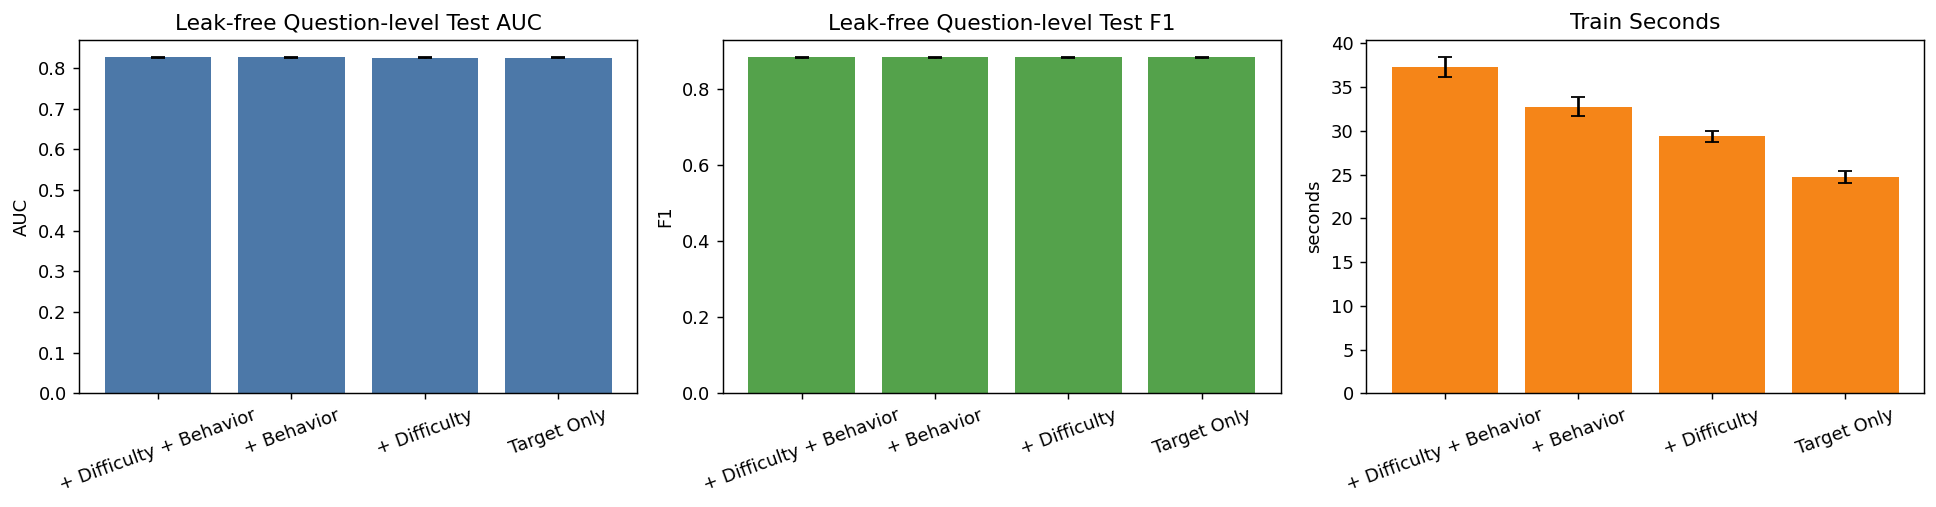

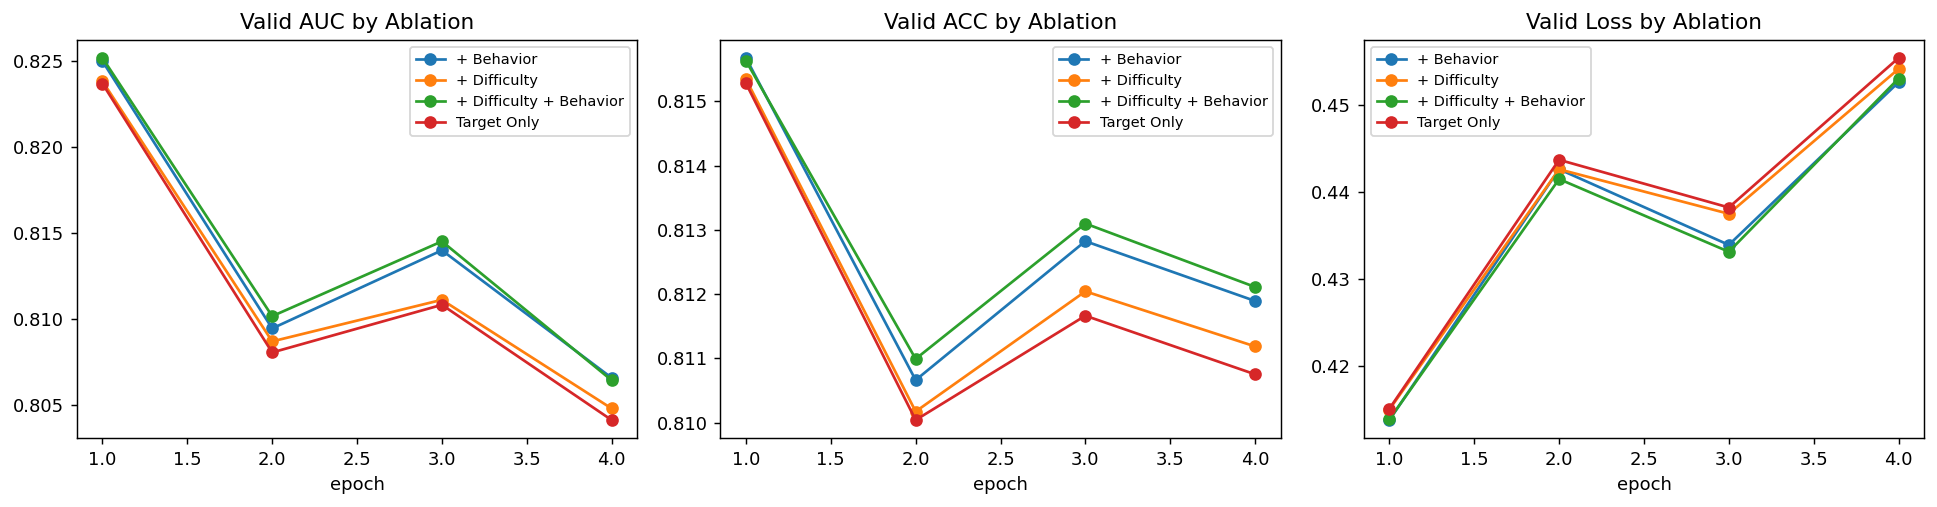

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = experiment_aggregate_df.sort_values('test_auc_mean', ascending=False).reset_index(drop=True)
labels = plot_df['label'].tolist()
x = np.arange(len(plot_df))

axes[0].bar(x, plot_df['test_auc_mean'], yerr=plot_df['test_auc_std'], capsize=4, color='#4c78a8')
axes[0].set_title('Leak-free Question-level Test AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylabel('AUC')

axes[1].bar(x, plot_df['test_f1_mean'], yerr=plot_df['test_f1_std'], capsize=4, color='#54a24b')
axes[1].set_title('Leak-free Question-level Test F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel('F1')

axes[2].bar(x, plot_df['train_seconds_mean'], yerr=plot_df['train_seconds_std'], capsize=4, color='#f58518')
axes[2].set_title('Train Seconds')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=20)
axes[2].set_ylabel('seconds')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for experiment_name, group in history_df.groupby('label'):
    mean_curve = group.groupby(['epoch', 'split'])[['auc', 'acc', 'loss']].mean().reset_index()
    valid_curve = mean_curve[mean_curve['split'] == 'valid']
    axes[0].plot(valid_curve['epoch'].to_numpy(), valid_curve['auc'].to_numpy(), marker='o', label=experiment_name)
    axes[1].plot(valid_curve['epoch'].to_numpy(), valid_curve['acc'].to_numpy(), marker='o', label=experiment_name)
    axes[2].plot(valid_curve['epoch'].to_numpy(), valid_curve['loss'].to_numpy(), marker='o', label=experiment_name)
axes[0].set_title('Valid AUC by Ablation')
axes[1].set_title('Valid ACC by Ablation')
axes[2].set_title('Valid Loss by Ablation')
for ax in axes:
    ax.set_xlabel('epoch')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



## 8. 结论

这版结果才是推荐用于汇报的 AHS-KT × Algebra2005 版本：

- 无同题多 KC label 展开泄露；
- 5 个 validation folds；
- 多 seed；
- ablation 对照表；
- 每个 fold 的 difficulty / behavior cluster 只从 train split 拟合。

如果要进一步做更严格的模型层改造，下一步可以把 `concept_combo_id` 换成真正的 multi-hot KC set encoder。